In [2]:
import numpy as np
import matplotlib.pyplot as plt
from DataVisualization import PlotBinaryClassData, PlotConfusionMatrix, PlotLabelsHistogram

# Machine Learning

from sklearn.datasets import make_moons
from sklearn.metrics import auc, balanced_accuracy_score, confusion_matrix, precision_recall_fscore_support, roc_curve
from sklearn.svm import SVC

from ipywidgets.widgets import IntSlider, interact

In [3]:
numSamples0 = 950
numSamples1 = 50

noiseLevael = 0.1

paramC = 1
kerneltype = 'linear'

numGridPts = 250

In [4]:
mX, vY = make_moons(n_samples= (numSamples0, numSamples1), noise=noiseLevael)

In [5]:
vIdx0 = vY == 0
vIdx1 = vY == 1

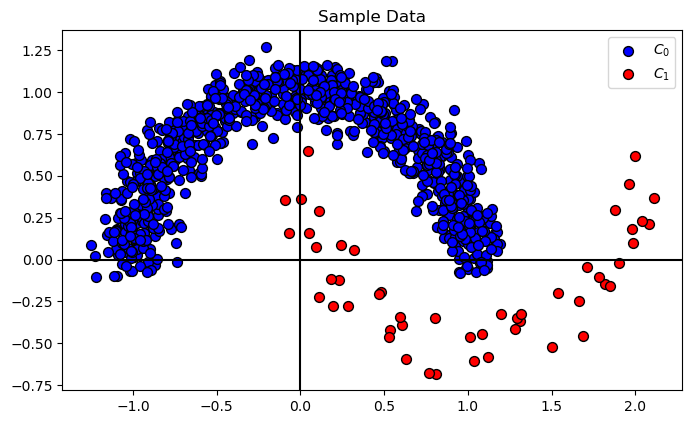

In [6]:
hA = PlotBinaryClassData(mX, vY, axisTitle='Sample Data')

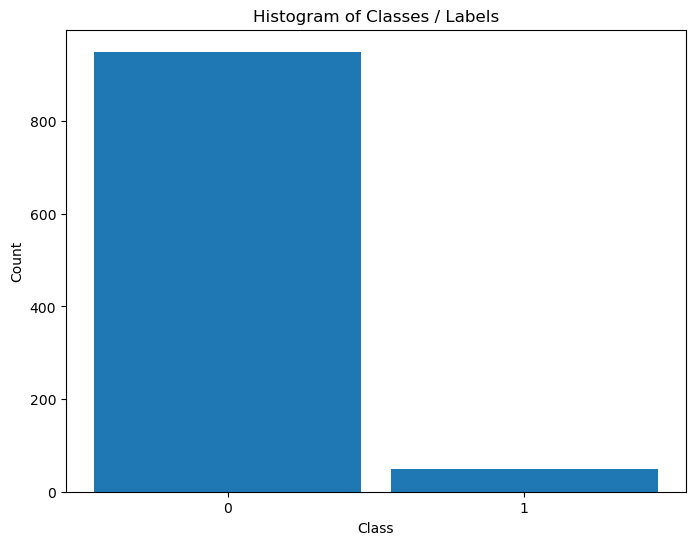

In [7]:
hA = PlotLabelsHistogram(vY)

In [8]:
oSVM = SVC(C=paramC, kernel=kerneltype).fit(mX, vY)
modelScore = oSVM.score(mX, vY)
print(f'The model score: {modelScore}' )

The model score: 0.976


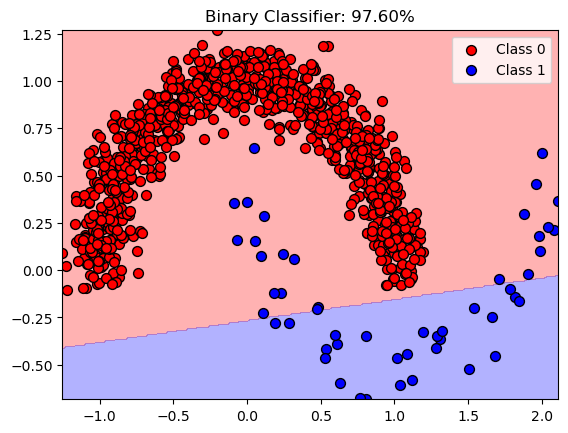

In [9]:
v0 = np.linspace(mX[:, 0].min(), mX[:, 0].max(), numGridPts)
v1 = np.linspace(mX[:, 1].min(), mX[:, 1].max(), numGridPts)

XX0, XX1 = np.meshgrid(v0, v1)
XX = np.c_[XX0.ravel(), XX1.ravel()]

Z = oSVM.predict(XX)
Z = Z.reshape(XX0.shape)

hF, hA = plt.subplots()
hA.contourf(XX0, XX1, Z, colors = ['red', 'blue'], alpha = 0.3, levels=[-0.5, 0.5, 1.5])
hA.scatter(mX[vIdx0, 0], mX[vIdx0, 1], s=50, c = 'red', edgecolors='k', label='Class 0')
hA.scatter(mX[vIdx1, 0], mX[vIdx1, 1], s=50, c ='blue', edgecolors = 'k', label='Class 1')
hA.set_title(f'Binary Classifier: {oSVM.score(mX, vY):0.2%}')
hA.legend()
plt.show()

In [10]:
oSVM.classes_

array([0, 1])

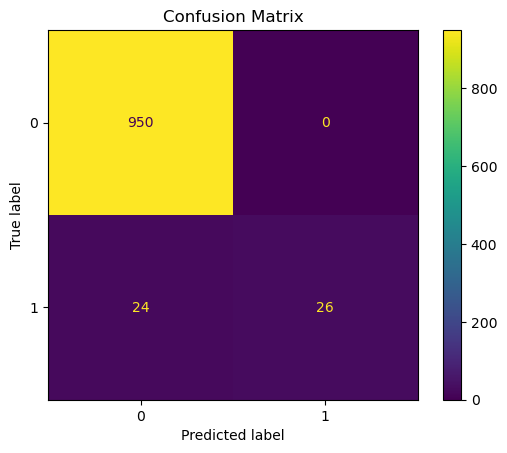

In [11]:
PlotConfusionMatrix(vY, oSVM.predict(mX), lLabels=oSVM.classes_)
plt.show()

In [12]:
vHatY = oSVM.predict(mX)
precision, recall, f1, _ = precision_recall_fscore_support(vY, vHatY, pos_label= 1, average='binary') # for two classes we have

print(f'Precision = {precision:0.3f}') #TP / (TP + FP)
print(f'Recall = {recall:0.3f}') # TP / (TP + FN)
print(f'F_1 = {f1:0.3f}') # Harmonic average between precision and recall

Precision = 1.000
Recall = 0.520
F_1 = 0.684


In [13]:
# Balanced accuracy: BA =1/2 (Recall + specificity)

_, specificity, _, _ = precision_recall_fscore_support(vY, vHatY, pos_label=0, average='binary')
print(f'Specificity = {specificity:0.2f}') # TN/ (TN + FP) ability to detect negatives

bAcc = 0.5 * (recall + specificity)

print(f'Accuracy = {modelScore:0.2f}')
print(f'Balanced Accuracy: {bAcc:0.2f}')


Specificity = 1.00
Accuracy = 0.98
Balanced Accuracy: 0.76


In [14]:
print(f'Balnced Accuracy = {balanced_accuracy_score(vY, vHatY):0.2%}')

Balnced Accuracy = 76.00%


In [15]:
# Analysis of the Scores F1 vs Balanced Accuracy

vP = np.linspace(0, 1, 1_000) # vector for range of precision
vR = np.linspace(0, 1, 1_000) # vector for range of recall

vP = vP[None, :]
vR = vR[:, None]

mS = np.where((vP + vR) > 0, vP + vR, 1e-9) # Avoid the situtarion of vP + vR = 0

mA = 0.5 * (vP + vR) # Balanced accuracy
mF1 = 2 * (vP * vR) / mS # F1

In [16]:
vR.shape

(1000, 1)

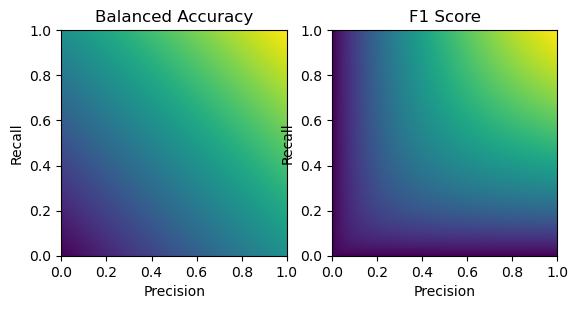

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=2)

ax[0].imshow(mA, vmin=0, vmax=1, aspect='equal', extent = (0, 1, 0, 1), origin = 'lower')
ax[0].set_title('Balanced Accuracy')
ax[0].set_xlabel('Precision')
ax[0].set_ylabel('Recall')

ax[1].imshow(mF1, vmin=0, vmax=1, aspect='equal', extent=(0, 1, 0, 1), origin = 'lower')
ax[1].set_title('F1 Score')
ax[1].set_xlabel('Precision')
ax[1].set_ylabel('Recall')
plt.show()


In [18]:
vScore = oSVM.decision_function(mX) # values proportinal to the distance from the separated hyperplane
vFP, vTP, vThr = roc_curve(vY, vScore, pos_label=1)
valAUC = auc(vFP, vTP)
print(f'AUC = {valAUC}')

AUC = 0.9551157894736841


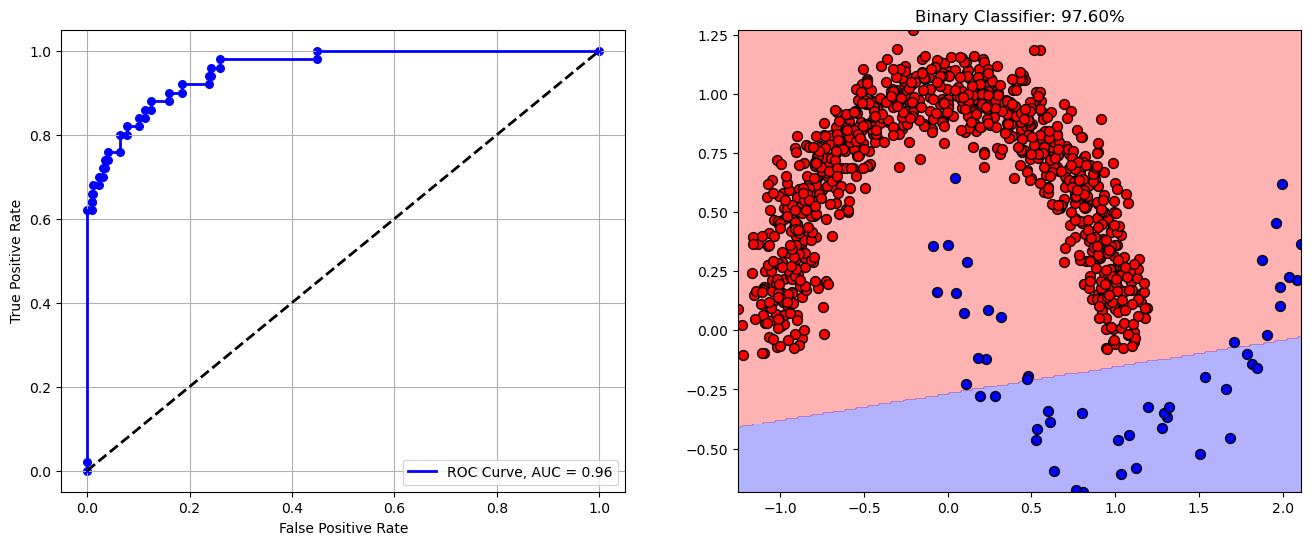

In [19]:
# my question "how the number of thresholds is set?"
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (16,6))

ax[0].plot(vFP, vTP, color = 'b', lw=2, label = f'ROC Curve, AUC = {valAUC:0.2f}')
ax[0].scatter(vFP, vTP, marker = 'o', s=30, color='blue')
ax[0].plot([0, 1], [0, 1], color = 'k', lw=2, linestyle='--') #guess level line
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].grid()
ax[0].legend()

ax[1].contourf(XX0, XX1, Z, colors = ['red', 'blue'], alpha = 0.3, levels=[-0.5, 0.5, 1.5])
ax[1].scatter(mX[vIdx0, 0], mX[vIdx0, 1], s=50, c = 'red', edgecolors='k', label='Class 0')
ax[1].scatter(mX[vIdx1, 0], mX[vIdx1, 1], s=50, c ='blue', edgecolors = 'k', label='Class 1')
ax[1].set_title(f'Binary Classifier: {oSVM.score(mX, vY):0.2%}')


plt.show()

In [20]:
vScore = oSVM.decision_function(XX)
mScore = vScore.reshape(XX0.shape)

def PlotRoc(idx):
    _, ax = plt.subplots(1, 2, figsize = (16,6 ))
    ax[0].plot(vFP, vTP, lw=2, color='blue', label= 'ROC Curve')
    ax[0].axvline(x=vFP[idx], color='green', lw=2, linestyle = '--')
    ax[0].set_title(f'alpha = {vThr[idx]:0.2f}')
    ax[0].set_xlabel('False Positive')
    ax[0].set_ylabel('True Positive')

    Z = mScore > vThr[idx]
    ax[1].contourf(XX0, XX1, Z, colors = ['red', 'blue'], alpha=0.3, levels = [-0.5, 0.5, 1.5])
    ax[1].scatter(mX[vIdx0, 0], mX[vIdx0, 1], s=50, c = 'red', edgecolors='k', label='Class 0')
    ax[1].scatter(mX[vIdx1, 0], mX[vIdx1, 1], s=50, c ='blue', edgecolors = 'k', label='Class 1')
    ax[1].set_title(f'Binary Classifier: {oSVM.score(mX, vY):0.2%}')

    plt.show()



In [21]:
idxSlider = IntSlider(min=0, max = len(vThr) - 1, step= 1 )

In [22]:
interact(
    lambda idx : PlotRoc(idx),
    idx = idxSlider
)

interactive(children=(IntSlider(value=0, description='idx', max=39), Output()), _dom_classes=('widget-interact…

<function __main__.<lambda>(idx)>

In [23]:
# AUC Area under curve of ROC - probability that randomly selected positive sample will be ranked higher that randomly selected negative sample

In [24]:
# Generate Synthetic Data Set
vYRoc = np.array(['P', 'P', 'N', 'P', 'P' , 'P' , 'N' , 'N' , 'P' , 'N' , 'P' , 'N' , 'P' , 'N' , 'N' , 'N' , 'P' , 'N' , 'P' , 'N'])
vSRoc = np.array([0.9, 0.8, 0.9, 0.6, 0.55, 0.51, 0.49, 0.43, 0.22, 0.39, 0.13, 0.31, 0.23, 0.22, 0.19, 0.15, 0.12, 0.11, 0.04, 0.01]) #<! Score values (Probability for Class 1)

vYRoc = np.where(vYRoc == 'P', 1, 0)

In [25]:
vFPRoc, vTPRoc, vThRoc = roc_curve(vYRoc, vSRoc, pos_label=1) #(vY, vScores, pos_lalbel =1 )
aucRoc = auc(vFPRoc, vTPRoc)

print(f'AUC = {aucRoc}')

AUC = 0.6


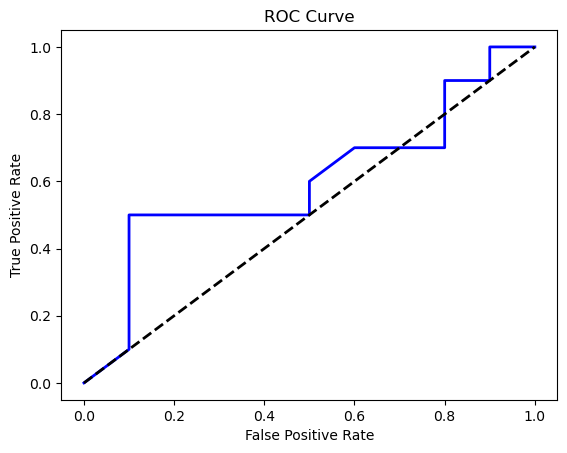

In [26]:
fig, ax = plt.subplots()

ax.plot(vFPRoc, vTPRoc, color = 'b', lw = 2, label = f'ROC Curve, AUC = {aucRoc:.3f}')
ax.plot([0, 1], [0, 1], color = 'k', lw = 2, linestyle = '--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
plt.show()

In [27]:
vSRoc

array([0.9 , 0.8 , 0.9 , 0.6 , 0.55, 0.51, 0.49, 0.43, 0.22, 0.39, 0.13,
       0.31, 0.23, 0.22, 0.19, 0.15, 0.12, 0.11, 0.04, 0.01])

In [35]:
# Empirical Calculation

vIdx0 = vYRoc == 0
vIdx1 = vYRoc == 1

# Counting the number of higher score for positive label

empAuc = np.mean(np.random.choice(vSRoc[vIdx1], 1000) > np.random.choice(vSRoc[vIdx0], 1000))
print(f'Empirical AUC: {empAuc}')

Empirical AUC: 0.602


In [36]:
# Estimation of label by score

vYEstRoc = vSRoc > 0.5
vYEstRoc = vYEstRoc.astype(np.int32)

In [38]:
# Tha balanced accuracy is the mean of TPR (Recall/sensitivity) and TNR (Speificity)
# It is equivalented to the accuracy weighted bu the class frequency

precisionRoc, recallRoc, f1Rock, _ = precision_recall_fscore_support(vYRoc, vYEstRoc, pos_label=1, average='binary')
tnRoc, fpRoc, fnRoc, tpRoc = confusion_matrix(vYEstRoc, vYEstRoc).ravel()
specificityRoc = tnRoc / (tnRoc + fpRoc)
print(precisionRoc, recallRoc, f1Rock)
0.5 * (recallRoc + specificityRoc)


0.8333333333333334 0.5 0.625


np.float64(0.75)

In [40]:
# Auc vs. Accuracy
empAcc = np.mean(vYEstRoc == vYRoc)
print(f'Empirical Accuracy : {empAcc}')

Empirical Accuracy : 0.7


In [ ]:
oSVM = SVC(C=paramC, kernel=kerneltype, probability=True).fit(mX, vY) #enables probability estimates via predict_proba()
modelScore = oSVM.score(mX, vY)
print(f"The model score on the data is {modelScore:0.2f}")

The model score on the data is 0.98


In [ ]:
vD = oSVM.decision_function(mX) #vector distances for every point from decision boundary
mP = oSVM.predict_proba(mX)

In [46]:
vD.shape

(1000,)